# Simulation 1

My first AREPO simulation. I'll generate a data file to be used. Columns will be:
- mass $M$
- pressure $P$
- temperature $T$
- radius $R$
- density $\rho$
- specificenergy $u$
- dm
- $H_1$
- ...

all in cgs.

# Setup

We will consider an ideal gas $n=3$ star with $M_\odot$ and $R_\odot$. Composition will be near solar with $M(H_1)=0.75M_{\odot}$ and $M(He_4)=0.25M_{\odot}$, so $\mu\approx0.61$.

I'll use $T=T_\odot$ as well

# Formulae

\begin{align}
    u=&\frac{P}{\rho(\gamma-1)}&\text{(Ideal gas)}\\
    P=&\rho\frac{k_BT}{\mu m_H}\\
    u=&\frac{1}{\gamma-1}\frac{k_BT}{\mu m_H}
\end{align}

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.cm as cm
from scipy.integrate import solve_ivp, quad, cumulative_trapezoid
from le_fun import *
import astropy.constants as const
import astropy.units as u

In [3]:
M = const.M_sun.cgs
R = const.R_sun.cgs
G = const.G.cgs
mu = 0.61 * const.m_p.cgs
beta = 0.9996
n = 3

t_span = [1e-10, 40]
y0 = (1 + 0j, 0 + 0j)
find_zero.terminal = True

print(R)
print(M.value)
print(G)

69570000000.0 cm
1.988409870698051e+33
6.674299999999999e-08 cm3 / (g s2)


In [ ]:
# Obtaining the mass of the star using ESM

def star_mass(beta, mu):
    """
    Return the stellar mass given the gas pressure ratio beta and mean molecular weight mu by the formulae:

    M = M_ch * ((1-beta)^0.5)/beta^2
    M_ch = 50M_sun * (0.6m_p/mu)^2

    Parameters
    ----------
    - beta: float
        Ratio between gas pressure and total pressure
    - mu: float
        Mean molecular weight
    
    Returns
    -------
    - M: float
        stellar mass in cgs
    """
    M_ch = 50 * const.M_sun.cgs * ((0.6 * const.m_p.cgs / mu) ** 2)
    return M_ch * (((1-beta)**0.5)/(beta**2))

print(star_mass(beta, mu)/const.M_sun.cgs)

0.01936512619683775


xi_1 = 6.8968486193769625


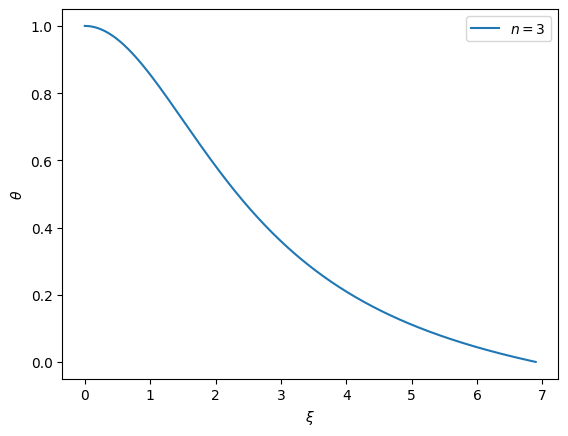

In [890]:
# The solution to our star

sol = solve_ivp(fun=le_derivatives, t_span=t_span, y0=y0, dense_output=True, max_step=1e-3, args=(n,), events=find_zero)
xi_1 = sol.t_events[0][0]
print(f'xi_1 = {xi_1}')

plt.plot(sol.t, sol.y[0].real, label=r'$n=3$')
plt.xlabel(r'$\xi$')
plt.ylabel(r'$\theta$')
plt.legend()
plt.show()

# Polytropic model

\begin{align*}
    P(r)=&K\rho(r)^{1+\frac{1}{n}}\\
    K=&j_nGM^{1-\frac{1}{n}}R^{\frac{3}{n}-1}
\end{align*}

With radiation and gas into account and with $n=3$,
\begin{align*}
P=&K(\beta)\rho^{4/3}\\
K^3=&\frac{3}{a}\frac{k^4}{\mu^4}\frac{1-\beta}{\beta^4}\\
a=&\frac{\pi^2k^4}{15\hbar^3c^3}
\end{align*}

In [891]:
def get_K(beta):
    """
    Calculate the polytropic constant K for a polytropic gas given its beta parameter.

    Parameters
    ----------
    beta : float
        The ratio of gas pressure to total pressure (dimensionless).

    Returns
    -------
    K: float
        The polytropic constant K in cgs units.
    """
    a = const.sigma_sb.cgs * (4/const.c.cgs)
    k = const.k_B.cgs
    K3 = (3/a) * ((k**4)/(mu**4)) * (1-beta)/(beta**4)
    return (K3**(1/3)).value

def get_polytrope_pressure(density):
    """
    Calculate the pressure of a polytropic gas given its density for an n=3 polytrope.

    Parameters
    ----------
    density : float
        The density of the gas in g/cm^3.

    Returns
    -------
    P: float
        The pressure of the gas in dyn/cm^2.
    """
    K = get_K(beta)
    return (K * density**(4/3)).value * (u.dyn / u.cm**2)

def get_polytrope_P(density, n, mass, radius):
    """
    Calculate the pressure of a polytropic gas given its density, polytropic index, mass, and radius.

    This pressure is purely gas pressure

    Parameters
    ----------
    density : float
        The density of the gas in g/cm^3.
    n : float
        The polytropic index of the gas (dimensionless).
    mass : float
        The mass of the gas in g.
    radius : float
        The radius of the gas in cm.

    Returns
    -------
    P: float
        The pressure of the gas in dyn/cm^2.
    """
    K = get_j(n) * G * (mass ** (1 - 1/n)) * (radius ** (3/n - 1))
    return K * density**(get_gamma(n))

def get_j(n):
    """
    Calculate the dimensionless constant j(n) for a polytropic gas given its polytropic index.

    Parameters
    ----------
    n : float
        The polytropic index of the gas (dimensionless).

    Returns
    -------
    j: float
        The dimensionless constant j(n).
    """
    if n == 3/2:
        return 0.424
    elif n == 3:
        return 0.364
    
def get_gamma(n):
    """
    Calculate the adiabatic index gamma for a polytropic gas given its polytropic index.

    Parameters
    ----------
    n : float
        The polytropic index of the gas (dimensionless).

    Returns
    -------
    gamma: float
        The adiabatic index of the gas (dimensionless).
    """
    return 1 + 1/n

# Density

For a polytrope, we have the equation

\begin{align}
    M=&4\pi\rho_cr_n^3[-\xi^2\theta'(\xi)]_{\xi_1}
\end{align}

Since we have the total mass, radius and numerical solutions to the Lane-Emden equation, we can rearrange to produce

\begin{align*}
    \rho_c=&\frac{M}{-4\pi R^2r_3\theta'(\xi_1)}\\
    r_n=&\sqrt{\frac{(n+1)K}{4\pi G\rho_c^{1-\frac{1}{n}}}}\\
    M=&4\pi \rho_c^{\frac{3}{2n}-\frac{1}{2}}\left(\frac{(n+1)K}{4\pi G}\right)^{3/2}(-\xi_1^2\theta'(\xi_1))
\end{align*}

\begin{align}
    \rho_c=&\left(\frac{MG^{3/2}\sqrt{4\pi}}{(n+1)^{3/2}K^{3/2}(-\xi_1^2\theta'(\xi_1))}\right)^{\frac{2n}{3-n}}
\end{align}

so for $n=3$ this doesn't work too well

In [892]:
# ignore

d_theta_xi_1 = sol.sol(sol.t_events[0][0])[1].real
print(d_theta_xi_1)

-0.04242975760445275


From a lookup table, we get $\rho_c=54.1825\overline{\rho}$

In [893]:
mean_density = 3 * M / (4 * np.pi * R**3)
central_density = 54.1825 * mean_density
print(f'Mean density: {mean_density}')
print(f'Central density: {central_density}')

Mean density: 1.4097798243075255 g / cm3
Central density: 76.3853953305425 g / cm3


In [894]:
central_gas_pressure = get_polytrope_P(central_density, n, M, R).to(u.dyn / u.cm**2) * beta
central_rad_pressure = central_gas_pressure * (1 - beta) / beta
central_rad_energy = 3 * central_rad_pressure.to(u.erg/u.cm**3)

print(central_gas_pressure)
print(central_rad_pressure)
print(central_rad_energy)

print(f'The resulting pressure divided by GM^2R^4 is {(central_gas_pressure + central_rad_pressure) / (G * M**2 / R**4)}, which is exact to what is tabulated for n=3 up to 2 decimal places.')

1.2445654367200907e+17 dyn / cm2
49802538484191.82 dyn / cm2
149407615452575.5 erg / cm3
The resulting pressure divided by GM^2R^4 is 11.052536491458442 s2 dyn / (cm g), which is exact to what is tabulated for n=3 up to 2 decimal places.


# Temperature

Now that we have the gas pressure and gas energy density, let's compute the temperature and total internal energy using

\begin{align}
u_{tot}=&u_{rad}+u_{gas}\\
u_{rad}=&aT^4\\
a=&\frac{4\sigma}{c}
\end{align}

In [895]:
def get_rad_T(rad_energy):
    """
    Calculate the temperature of a radiation field given its energy density.

    Parameters
    ----------
    rad_energy : float
        The energy density of the radiation field in erg/cm^3.

    Returns
    -------
    T: float
        The temperature of the radiation field in K.
    """
    a = (4 * const.sigma_sb/const.c).to(u.erg / (u.cm**3 * u.K**4))
    rad_energy = rad_energy.to(u.erg / u.cm**3)
    return (rad_energy / a)**(1/4)

# Obtaining the data

If everything worked as intended, I should end up with functions to obtain:
- pressure at each radius step
- temperature at each radius step
- radius as a function of xi
- density at each radius
- specific energy (density) at each radius
- dm at each radius
- h1 at each radius
- he4 at each radius

In [896]:
# Density as a function of xi:

def density(xi):
    """
    Calculate the density of a polytropic gas as a function of the dimensionless radius xi.

    p(xi) = p_c * theta(xi)^n

    Parameters
    ----------
    xi : float
        The dimensionless radius (dimensionless).

    Returns
    -------
    density: float
        The density of the gas in g/cm^3.
    """
    val = central_density * (sol.sol(xi)[0]**n).real
    return val

# Test:
print(f'Density at xi_1: {density(xi_1)}')
print(f'Density at xi=0: {density(0)}')

Density at xi_1: -8.117321166608824e-51 g / cm3
Density at xi=0: 76.3853953305425 g / cm3


In [897]:
# Total pressure as a function of xi:

def get_tot_P(xi):
    """
    Calculate the total pressure of a polytropic gas as a function of the dimensionless radius xi.

    Parameters
    ----------
    xi : float
        The dimensionless radius (dimensionless).

    Returns
    -------
    P: float
        The total pressure of the gas in dyn/cm^2.
    """
    return get_polytrope_pressure(density(xi))

# Gas and radiation pressure:
def get_gas_P(xi):
    return get_tot_P(xi) * beta

def get_rad_P(xi):
    return get_tot_P(xi) * (1 - beta)

print(f'Total gas pressure at xi=0: {get_gas_P(0)}')

Total gas pressure at xi=0: 1.218959610236448e+17 dyn / cm2


In [898]:
# Energy densities as a function of xi:

def get_gas_energy(xi):
    """
    Calculate the gas internal energy density of a polytropic gas as a function of the dimensionless radius xi.

    Parameters
    ----------
    xi : float
        The dimensionless radius (dimensionless).

    Returns
    -------
    energy: float
        The gas internal energy density of the gas in erg/cm^3.
    """
    return 3/2 * get_gas_P(xi)

def get_rad_energy(xi):
    """
    Calculate the radiation energy density of a polytropic gas as a function of the dimensionless radius xi.

    Parameters
    ----------
    xi : float
        The dimensionless radius (dimensionless).

    Returns
    -------
    energy: float
        The radiation energy density of the gas in erg/cm^3.
    """
    return 3 * get_rad_P(xi)

print(f'Gas energy density at xi=0: {get_gas_energy(0)}')
print(f'Radiation energy density at xi=0: {get_rad_energy(0)}')

Gas energy density at xi=0: 1.828439415354672e+17 dyn / cm2
Radiation energy density at xi=0: 146333686703038.84 dyn / cm2


In [899]:
# Temperature as a function of xi:

def get_T_rho(xi):
    """
    Calculate the temperature of a polytropic gas as a function of its density.

    Parameters
    ----------
    rho : float
        The density of the gas in g/cm^3.

    Returns
    -------
    T: float
        The temperature of the gas in K.
    """
    a = const.sigma_sb.cgs * (4/const.c.cgs)
    rho = density(xi).cgs
    T3 = ((1-beta)/beta) * (3 * rho * const.k_B.cgs)/(mu * a)
    return (T3 ** (1/3)).to(u.K)

def get_T(xi):
    """
    Calculate the temperature of a polytropic gas as a function of the dimensionless radius xi.

    Parameters
    ----------
    xi : float
        The dimensionless radius (dimensionless).

    Returns
    -------
    T: float
        The temperature of the gas in K.
    """
    return get_rad_T(get_rad_energy(xi))

print(f'Temperature at xi=0: {get_T(0)}')
print(f'Temp at xi=0:{get_T_rho(0)}')

Temperature at xi=0: 11792973.491034582 K
Temp at xi=0:11792973.491034579 K


In [900]:
# Radius as a function of xi:

def get_r(xi):
    """
    Calculate the radius of a polytropic gas as a function of the dimensionless radius xi.

    Parameters
    ----------
    xi : float
        The dimensionless radius (dimensionless).

    Returns
    -------
    r: float
        The radius of the gas in cm.
    """
    return xi * R / xi_1

print(f'Radius at xi_1: {get_r(xi_1)/R} Solar radii')

Radius at xi_1: 1.0 Solar radii


In [901]:
# mass of shell as a function of xi:

def solution_integrand(xi):
    return (R/xi_1) * (4 * np.pi * (get_r(xi)**2) * density(xi)).value

def get_dm(xi_start, xi_end):
    """
    Calculate the mass of a shell of a polytropic gas between two dimensionless radii xi_start and xi_end.

    Parameters
    ----------
    xi_start : float
        The starting dimensionless radius (dimensionless).
    xi_end : float
        The ending dimensionless radius (dimensionless).

    Returns
    -------
    dm: float
        The mass of the shell in g.
    """
    return cumulative_trapezoid(solution_integrand(np.linspace(xi_start, xi_end, 1000)), np.linspace(xi_start, xi_end, 1000))[-1] * u.g

xi_span = np.linspace(0, xi_1, 10)
temp_tot_M = 0
for i in range(len(xi_span) - 1):
    dm = get_dm(xi_span[i], xi_span[i+1])
    temp_tot_M += dm
    print(f'Mass between r={get_r(xi_span[i])} and r={get_r(xi_span[i+1])}: {dm}')

print(temp_tot_M/M)

print(get_dm(xi_span[0], xi_span[-1]))

Mass between r=0.0 cm and r=7730000000.0 cm: 1.2484216930142233e+32 g
Mass between r=7730000000.0 cm and r=15460000000.0 cm: 5.226632786021144e+32 g
Mass between r=15460000000.0 cm and r=23190000000.000004 cm: 6.023098167099155e+32 g
Mass between r=23190000000.000004 cm and r=30920000000.0 cm: 4.082270348006836e+32 g
Mass between r=30920000000.0 cm and r=38650000000.0 cm: 2.0927791427405215e+32 g
Mass between r=38650000000.0 cm and r=46380000000.00001 cm: 8.703686602673874e+31 g
Mass between r=46380000000.00001 cm and r=54110000000.00001 cm: 2.8042849491854638e+31 g
Mass between r=54110000000.00001 cm and r=61840000000.0 cm: 5.671795019209495e+30 g
Mass between r=61840000000.0 cm and r=69570000000.0 cm: 3.3883980225294796e+29 g
1.000000348685753
1.9884105640283143e+33 g


In [902]:
# Mass fractions of H1 and He4:

def get_HMass(dm, X=0.75):
    """
    Calculate the mass of hydrogen in a shell of a polytropic gas given the mass of the shell and the hydrogen mass fraction.

    Parameters
    ----------
    dm : float
        The mass of the shell in g.
    X : float
        The hydrogen mass fraction (dimensionless).

    Returns
    -------
    H_mass: float
        The mass of hydrogen in the shell in g.
    """
    return dm * X

def get_HeMass(dm, Y=0.25):
    """
    Calculate the mass of helium in a shell of a polytropic gas given the mass of the shell and the helium mass fraction.

    Parameters
    ----------
    dm : float
        The mass of the shell in g.
    Y : float
        The helium mass fraction (dimensionless).

    Returns
    -------
    He_mass: float
        The mass of helium in the shell in g.
    """
    return dm * Y

# Generating the data

Now that we have all of the necessary functions, we are ready to generate the data file for AREPO. In the data file, the radius decreases from the surface to the core, going from line 2 downwards. (Line 1 contains the names of the columns) Each column is separated by a tab. The names of the columns are exactly:

- mass	
- pressure	
- temperature	
- radius	
- density	
- specificenergy	
- dm	
- h1	
- he3	
- he4	
- c12	
- n14	
- o16	
- ne20	
- mg24


In [903]:
# Generating an array for xi, leaving out the last point as the density may become negative.
xi_array = np.linspace(1e-8, xi_1, 1001)[:-1]

In [904]:
# initialising variables
mass = [0 for _ in xi_array]
dm = [0 for _ in xi_array]
pressure = [0 for _ in xi_array]
temperature = [0 for _ in xi_array]
radius = [0 for _ in xi_array]
rho = [0 for _ in xi_array]
specificenergy = [0 for _ in xi_array]
h1 = [0 for _ in xi_array]
he4 = [0 for _ in xi_array]
c12 = [0 for _ in xi_array]
he3 = [0 for _ in xi_array]
n14 = [0 for _ in xi_array]
o16 = [0 for _ in xi_array]
ne20 = [0 for _ in xi_array]
mg24 = [0 for _ in xi_array]

In [905]:
# dm
for i in range(len(xi_array) - 1):
    dm[i] = get_dm(xi_array[i], xi_array[i+1]).value
print(dm[0])

# mass
mass = [sum(dm[:i+1]) for i in range(len(dm))]
print(mass[-1])

# pressure
for i in range(len(xi_array)):
    pressure[i] = get_tot_P(xi_array[i]).value
print(pressure[0])

# temperature
for i in range(len(xi_array)):
    temperature[i] = get_T_rho(xi_array[i]).value
print(temperature[-1])

# radius
for i in range(len(xi_array)):
    radius[i] = get_r(xi_array[i]).value
print(radius[-1])

# density
for i in range(len(xi_array)):
    rho[i] = density(xi_array[i]).value
print(rho[0])

# specific energy
for i in range(len(xi_array)):
    specificenergy[i] = get_gas_energy(xi_array[i]).value + get_rad_energy(xi_array[i]).value
print(specificenergy[0])

1.0773600256370225e+26
1.9884105640262172e+33
1.219447389192127e+17
3454.4513264757134
69500430000.10088
76.3853953305426
1.8299027522217056e+17


In [906]:
# Ratios of masses of different elements:
for i in range(len(xi_array)):
    h1[i] = get_HMass(dm[i])
    he4[i] = get_HeMass(dm[i])

# All the rest are zero by assumption.
print(h1[0] + he4[0], dm[0])

1.0773600256370225e+26 1.0773600256370225e+26


Now we import pandas and generate the csv

In [907]:
import pandas as pd

In [908]:
data = {
    'mass': mass[::-1],
    'pressure': pressure[::-1],
    'temperature': temperature[::-1],
    'radius': radius[::-1],
    'density': rho[::-1],
    'specificenergy': specificenergy[::-1],
    'dm': dm[::-1],
    'h1': h1[::-1],
    'he3': he3[::-1],
    'he4': he4[::-1],
    'c12': c12[::-1],
    'n14': n14[::-1],
    'o16': o16[::-1],
    'ne20': ne20[::-1],
    'mg24': mg24[::-1]
}
df = pd.DataFrame(data)

df.to_csv('AREPO_sim1_schen.data', sep='\t', index=False)

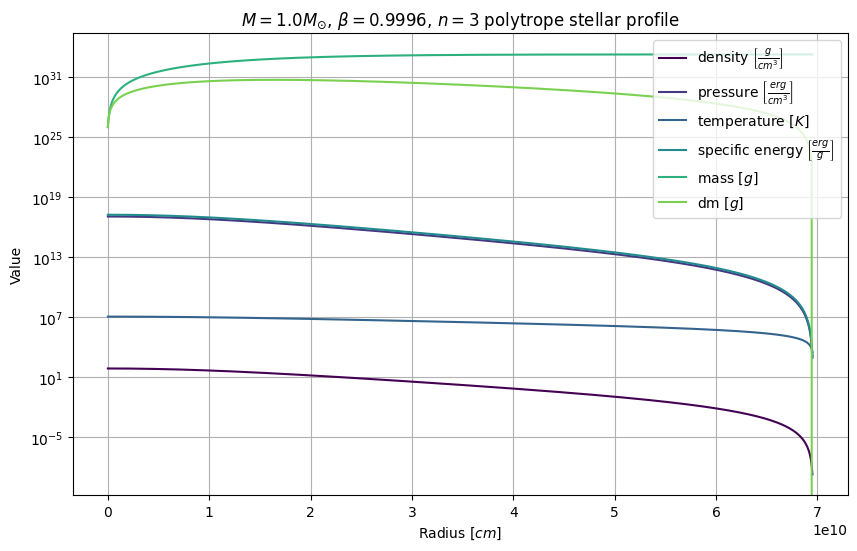

In [916]:
colours = cm.viridis(np.linspace(0, 0.8, 6))

plt.figure(figsize=(10, 6), dpi=100)
plt.plot(radius, rho, color=colours[0], label=r'density $\left[\frac{g}{cm^3}\right]$')
plt.plot(radius, pressure, color=colours[1], label=r'pressure $\left[\frac{erg}{cm^3}\right]$')
plt.plot(radius, temperature, color=colours[2], label=r'temperature $[K]$')
plt.plot(radius, specificenergy, color=colours[3], label=r'specific energy $\left[\frac{erg}{g}\right]$')
plt.plot(radius, mass, color=colours[4], label=r'mass $[g]$')
plt.plot(radius, dm, color=colours[5], label=r'dm $[g]$')

plt.grid()
# plt.xscale('log')
plt.legend()
plt.xlabel(r'Radius $[cm]$')
plt.ylabel('Value')
plt.title(r'$M=%.1fM_{\odot}$, $\beta=%.4f$, $n=3$ polytrope stellar profile' % ((M/const.M_sun), beta))
plt.yscale('log')
plt.show()